<a href="https://colab.research.google.com/github/pretyjoshi/LgccPythonProject/blob/main/python_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PYTHON PROJECT 2**
Exploration of public health data

The goal of this project is to analyze diabetes data, perform data cleaing, comparative analysis,  vizualization,  and summarizing results.


In [1]:
# Basic imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
#Plot settings
plt.style.use('default')
sns.set(style='whitegrid')

# Versions
import sys
print('Python version:',sys.version)
print('Pandas version:',pd.__version__)
print('Seaborn version:',sns.__version__)


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas version: 2.2.2
Seaborn version: 0.13.2


In [2]:
#1.Load Dataset

missing_values = ["?", "missing", "NA", "NULL",  "n/a"," " ,""] # or any other specific markers that shoud be considerd as missing value
df=pd.read_csv("https://raw.githubusercontent.com/pretyjoshi/LgccPythonProject/refs/heads/main/diabetic_data.csv",na_values=missing_values,low_memory=False)
#Shape of dataset
print('Shape (rows,columns):',df.shape)

## Finding 1:
## Data has 101766 entries for 50 variables


Shape (rows,columns): (101766, 50)


In [3]:
#2.Quick Data Overview

#Peek at the data
print('First 5 rows')
display(df.head())

print ('Last 5 rows')
display(df.tail())

## Finding 2:
## There seems to be many missing values in 'weight'

First 5 rows


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Last 5 rows


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [4]:
#Column names
print('\nColumn names : ')
print(df. columns.tolist())

#Data types
print('\nData types:')
print(df.dtypes)

#Info (non-null counts,dtypes)
print('\nDataFrame info:')
df.info()

# Basic numeric stats
print('\nDescriptive statistics (numeric columns):')
display(df.describe(include='object'))

# Memory usage
print('\nMemory usage(bytes):')
print(df.memory_usage(deep=True))

## Finding 2:
## Data is mixed of numeric and categorical values
## Some categorical or objects (ID) variables are wrongly typed as int64
## 'Weight' and 'glucose serum' appears to have least non-null values.



Column names : 
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age         

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,99493,101766,101766,3197,61510,51817,101745,101408,100343,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,5,3,10,9,17,72,716,748,789,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),[75-100),MC,InternalMedicine,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,1336,32439,14635,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864



Memory usage(bytes):
Index                           132
encounter_id                 814128
patient_nbr                  814128
race                        5947965
gender                      5503047
age                         5701528
weight                      3336151
admission_type_id            814128
discharge_disposition_id     814128
admission_source_id          814128
time_in_hospital             814128
payer_code                  4425202
medical_specialty           4963929
num_lab_procedures           814128
num_procedures               814128
num_medications              814128
number_outpatient            814128
number_emergency             814128
number_inpatient             814128
diag_1                      5309285
diag_2                      5302301
diag_3                      5277581
number_diagnoses             814128
max_glu_serum               3368778
A1Cresult                   3589834
metformin                   5264600
repaglinide                 5195692
nategl

In [5]:
# Convering the type of categorical values that are read as numeric by default.
# Numeric columns to category
df['encounter_id'] = df['encounter_id'].astype('category') # by default it takes  ID TYPE name  as numeric, but it shoudl be category
df['patient_nbr'] = df['patient_nbr'].astype('category') # by default it takes  ID TYPE name  as numeric, but it shoudl be category
df['discharge_disposition_id'] = df['discharge_disposition_id'].astype('category') # by default it takes  ID TYPE name  as numeric, but it shoudl be category
df['admission_source_id'] = df['admission_source_id'].astype('category') # by default it takes  ID TYPE name  as numeric, but it shoudl be category
df['admission_type_id'] = df['admission_type_id'].astype('category') # by default it takes  ID TYPE name  as numeric, but it shoudl be category

In [6]:
#3.Missing Values Analysis


# Count of missing values
print('Missing values per column (count):')
missing_count=df.isnull().sum()
display(missing_count)

# Percentage of missing values
missing_pct=df.isnull().mean()* 100
print('\nColumns sorted by missing percentage:')
display(missing_pct.sort_values(ascending=False))

## Finding :
# Top three columns with missing vaues are:
# Weight	        96.85%
# max_glu_serum	  94.75%
# A1Cresult	      83.3%

Missing values per column (count):


,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0



Columns sorted by missing percentage:


,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
patient_nbr,0.000000


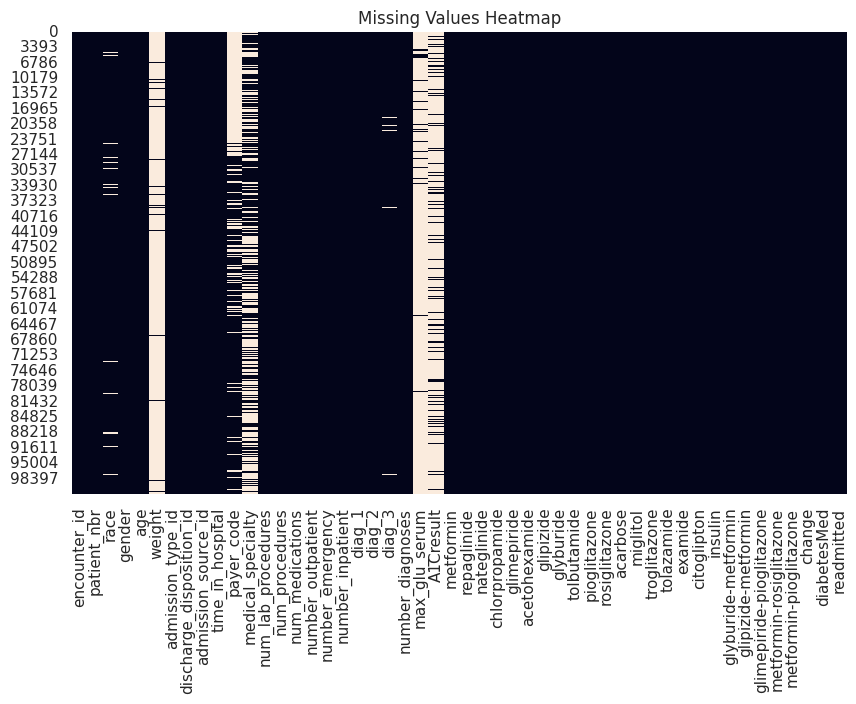

In [7]:
# Visual:missingness heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False,xticklabels=True)
plt.title ('Missing Values Heatmap')
plt.show()

In [8]:
#Duplicate Rows
# Number of duplicate rows
num_duplicates=df.duplicated().sum()
print('Number of duplicate rows:',num_duplicates)

#Show duplicate rows (if any)

if num_duplicates > 0:
    print('\nDuplicate rows:'),
    display(df[df.duplicated()])
else:
    print('No duplicate rows found.')

# Create a version without dulicates(if you want to use it later)
df_no_dupes =df.drop_duplicates().copy()
print('Shape after removing dupicates:',df_no_dupes.shape)

# Finding:
# No duplicated rows

Number of duplicate rows: 0
No duplicate rows found.
Shape after removing dupicates: (101766, 50)


In [10]:
#5.Separate Numeric and Categorical columns

# Numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Numeric columns:', num_cols)

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

Numeric columns: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categorical columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


Numeric feature statistics:


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


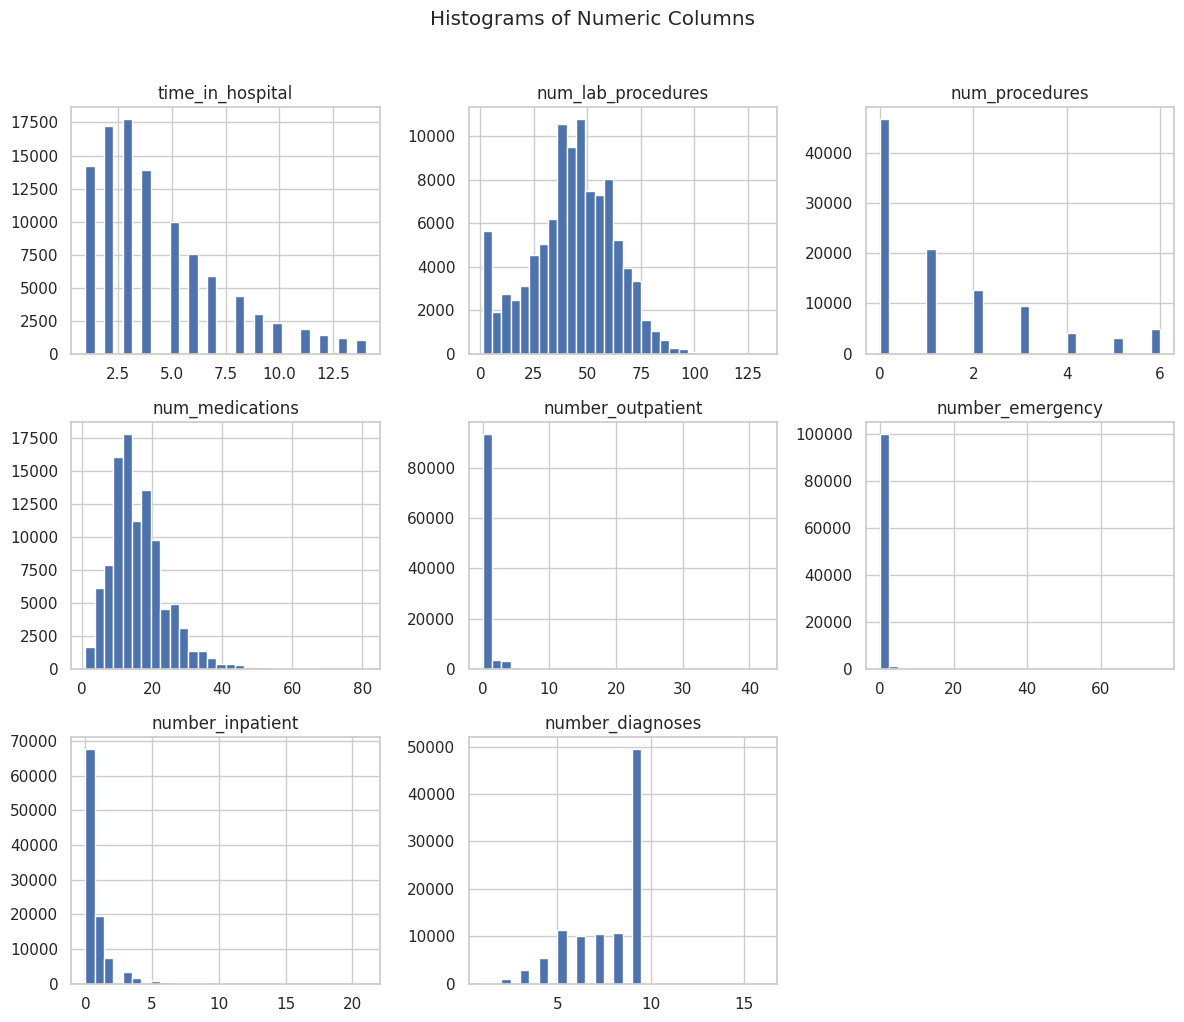

In [11]:
#6.Univariate Analysis

#6.1 Numeric Features

#Descriptive statistics(transposed for readability)
print('Numeric feature statistics:')
display(df[num_cols].describe().T)

#Histogroms for all numeric columns
df[num_cols].hist(figsize=(12,10),bins=30)
plt.suptitle('Histograms of Numeric Columns',y=1.02)
plt.tight_layout()
plt.show()


#Finding
# Data shows close to normal ditribution for 'num_lab_procedures' and 'num_medication'
# 'Num_diagnosis' looks left-skewed
# 'num_inpatients', 'time_in_hospital', and 'num_procedures' are right-skewed


column:gender


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3



column:age


,count
age,
[70-80),26068
[60-70),22483
[50-60),17256
[80-90),17197
[40-50),9685
[30-40),3775
[90-100),2793
[20-30),1657
[10-20),691


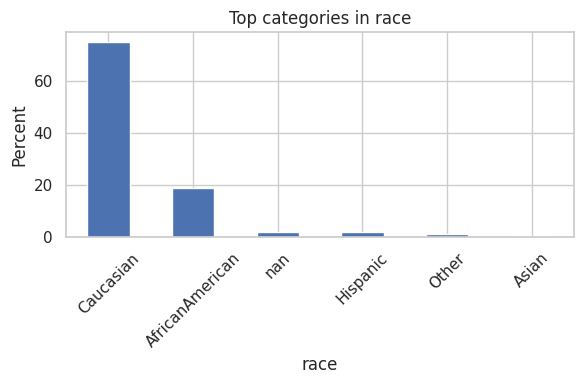

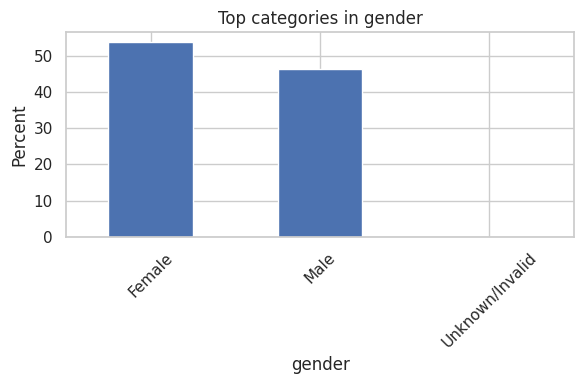

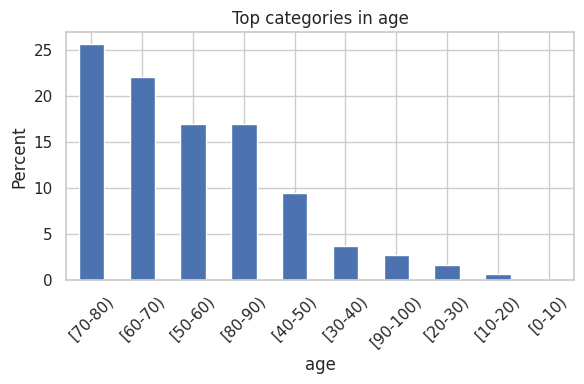

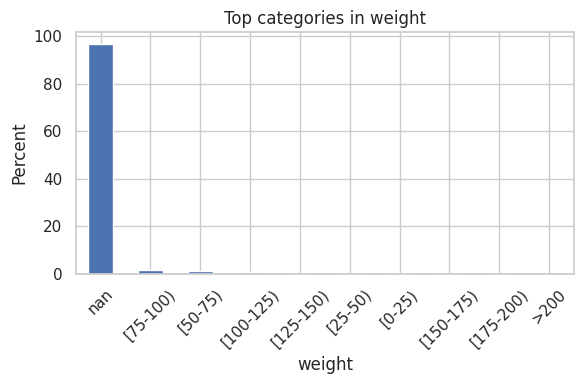

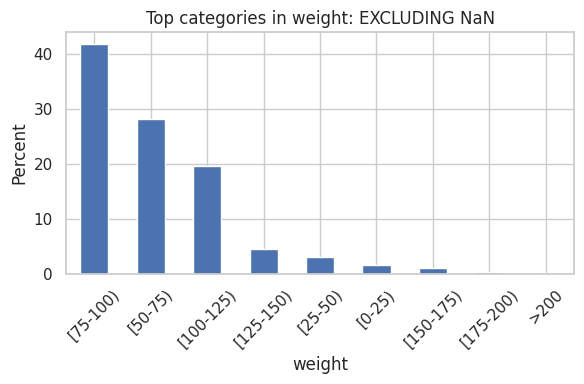

In [34]:
#6.2 Categorical Features

#Value counts for each categorical column
for col in cat_cols[3:5]:    ##### This include coloum 2, 3, and 4
  print(f"\ncolumn:{col}"),
  display(df[col].value_counts(dropna=False)),
  #display((df[col].value_counts(normalize=True,dropna=False)*100).rename('percentage')),

#Bar plots for  categories col in cat_cols:
 # 0-5     'encounter_id','patient_nbr','race','gender','age','weight',
 # 6-10     'admission_type_id','discharge_disposition_id','admission_source_id','payer_code','medical_specialty',
 # 11-15     'diag_1','diag_2','diag_3','max_glu_serum','A1Cresult',
 # 16-20     'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
 # 21-25     'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
 # 26-30    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
 # 31-35      'examide','citoglipton', 'insulin','glyburide-metformin','glipizide-metformin',
 # 36-41    'glimepiride-pioglitazone','metformin-rosiglitazone', 'metformin-pioglitazone','change','diabetesMed','readmitted']


for col in cat_cols[2:6]:    ##### This include coloum 2, 3, 4, 5 and 6. CHNAGE THE INDICES TO PLOT REQUIRED COLUMNS. Provide a range. The function not include far right.
  plt.figure(figsize=(6,4)),
  (df[col].value_counts(normalize=True,dropna=False)*100).rename('percentage').plot(kind='bar'),
  plt.title(f'Top categories in {col}'),
  plt.ylabel('Percent'),
  plt.xticks(rotation=45),
  plt.tight_layout(),
  plt.show()


for col in cat_cols[5:6]:    ##### In the plot for weight, 'missing value' were dominating, so I dropped NaN here to view available distribution.
  plt.figure(figsize=(6,4)),
  (df[col].value_counts(normalize=True,dropna=True)*100).rename('percentage').plot(kind='bar'),
  plt.title(f'Top categories in {col}: EXCLUDING NaN'),
  plt.ylabel('Percent'),
  plt.xticks(rotation=45),
  plt.tight_layout(),
  plt.show()


Target column: age

Target value counts:


,count
age,
[70-80),26068
[60-70),22483
[50-60),17256
[80-90),17197
[40-50),9685
[30-40),3775
[90-100),2793
[20-30),1657
[10-20),691



Target value percentages:


,proportion
age,
[70-80),25.615628
[60-70),22.092840
[50-60),16.956547
[80-90),16.898571
[40-50),9.516931
[30-40),3.709490
[90-100),2.744532
[20-30),1.628245
[10-20),0.679009


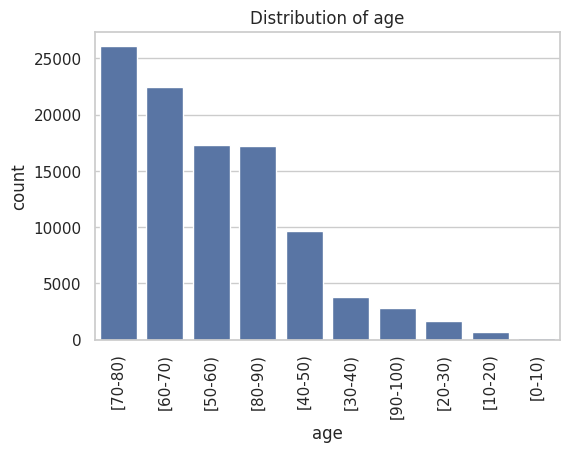

In [39]:
#7.Target Variable
#set your target column name here(if you have one)
target_col = 'age'

if target_col is not None and target_col in df.columns:
  print ('Target column:',target_col)
  print('\nTarget value counts:')
  display(df[target_col].value_counts())
  print('\nTarget value percentages:')
  display(df[target_col].value_counts(normalize=True)* 100)
  plt.figure(figsize=(6,4))
  plt.xticks(rotation=90)
  order_dec = df[target_col].value_counts(ascending=False).index
  sns.countplot(x=target_col, data=df, order=order_dec)
  plt.title(f'Distribution of {target_col}')
  plt.show()
else:
  print('No valid target column set. Set target_col to a column name to analyze target')


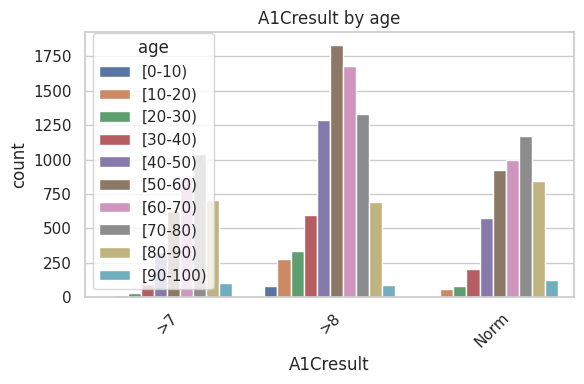

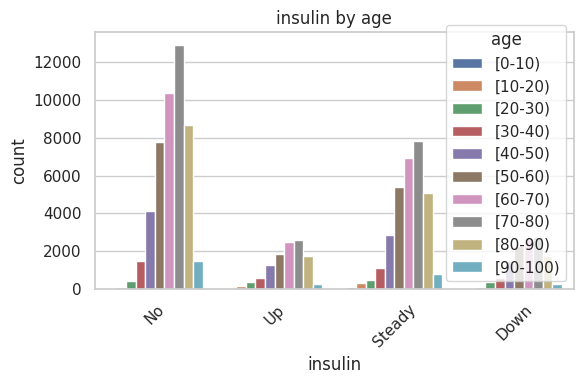

In [41]:
## 8. Bivariate Analysis: With race as target
## Categorical vs Target: countplots
if target_col is not None and target_col in df.columns:

    #cat_cols_ex_target = [c for c in cat_cols if c != target_col]
    cat_cols_ex_target= [cat_cols[15], cat_cols[33]]  # 15 and 33 are glucose and insulin reords respectively.

    for col in cat_cols_ex_target: ## sselected two columns
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, hue=target_col, data=df)
        plt.title(f'{col} by {target_col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print('No target column set. Skipping categorical vs target analysis.')

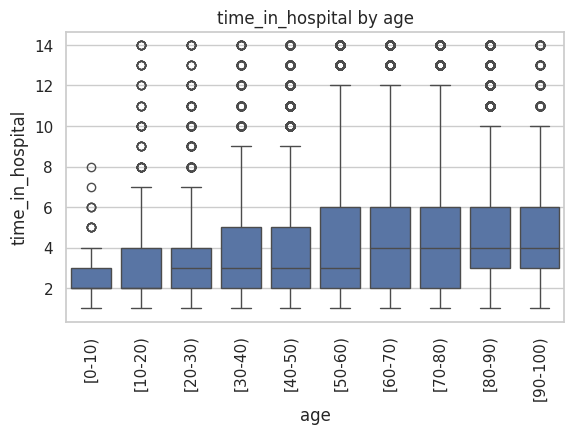

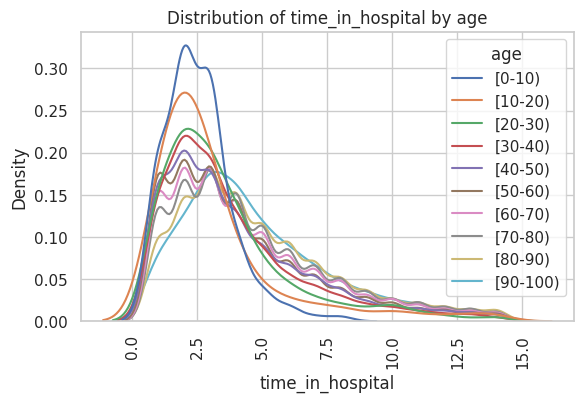

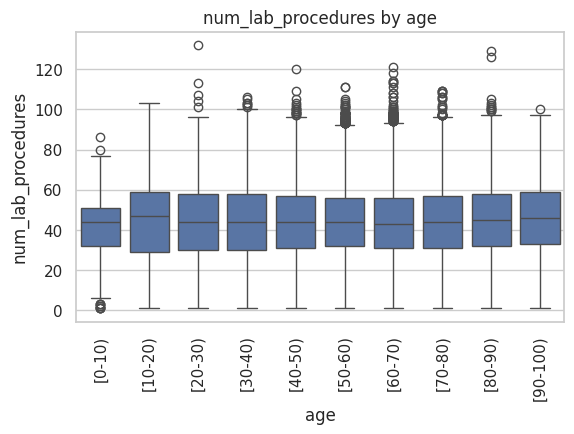

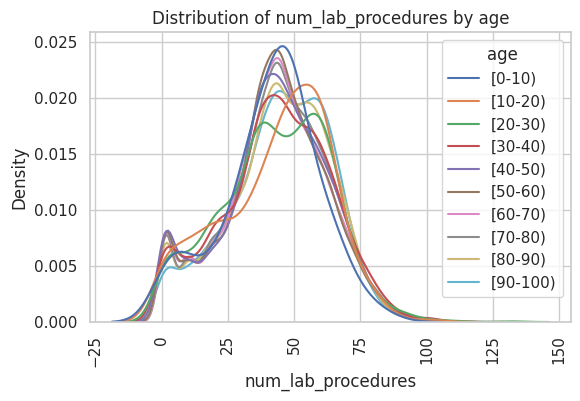

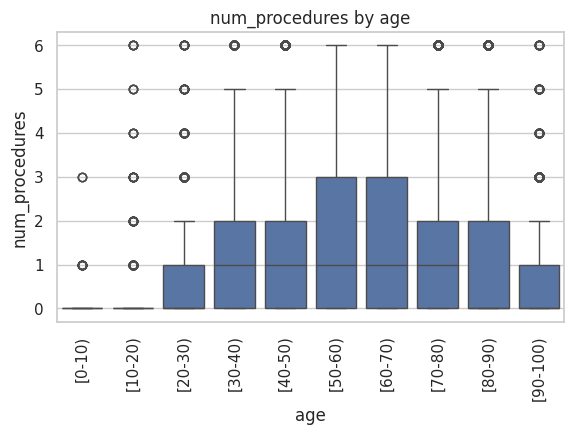

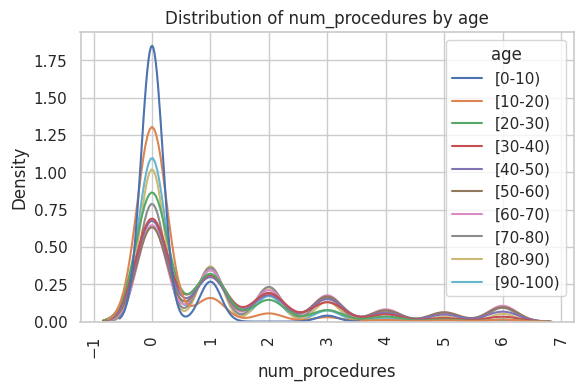

In [47]:
#8. Bivariate Analysis
## Target: boxplots and/or KDE
#NUmeric columns
# 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
# 'number_emergency', 'number_inpatient', 'number_diagnoses'
if target_col is not None and target_col in df.columns:

    for col in num_cols[0:3]:
        if col == target_col:
            continue

        plt.figure(figsize=(6, 4))
        sns.boxplot(x=target_col, y=col, data=df)
        plt.title(f'{col} by {target_col}')
        plt.tight_layout()
        plt.xticks(rotation=90)
        plt.show()

        # Optional KDE plot
        plt.figure(figsize=(6, 4))
        sns.kdeplot(data=df, x=col, hue=target_col, common_norm=False)
        plt.title(f'Distribution of {col} by {target_col}')
        plt.tight_layout()
        plt.xticks(rotation=90)
        plt.show()
else:
    print('No target column set. Skipping numeric vs target analysis.')

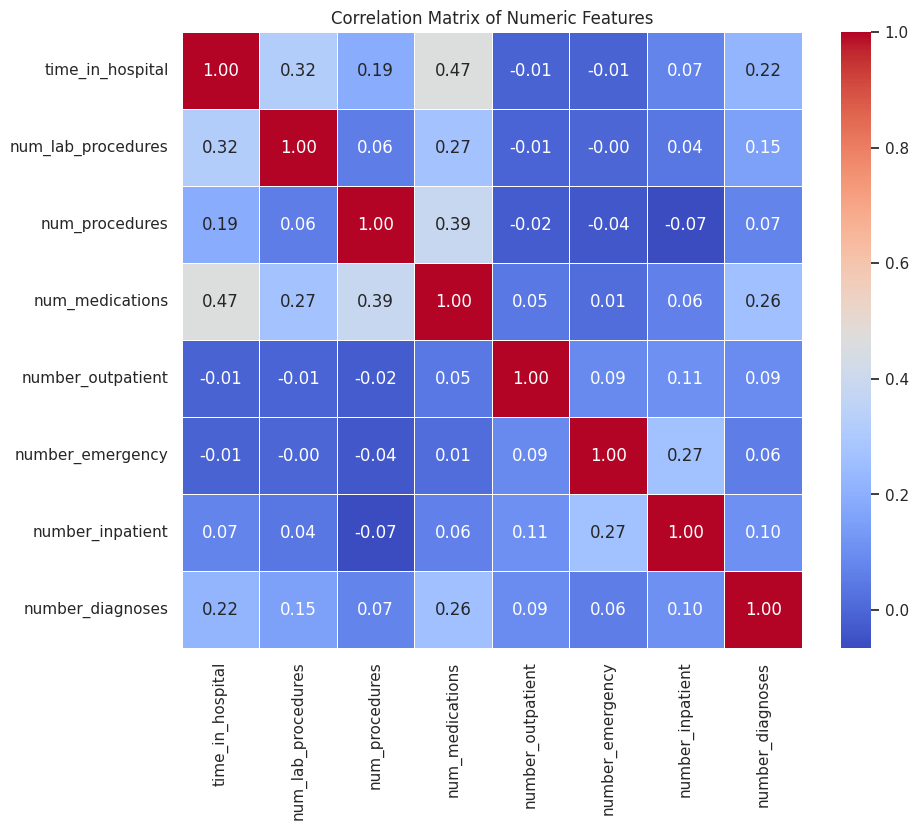

In [48]:
#9. Correlation Analysis(Numeric)
corr=df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Finding:
# Time_in_hospital shows decent positve correlationa with Num_medication and  num_lan procedues
# Other weak positive corrlations are between  num_lab_procedure vs num_lab_medication and num_inpatients vs num_emergency

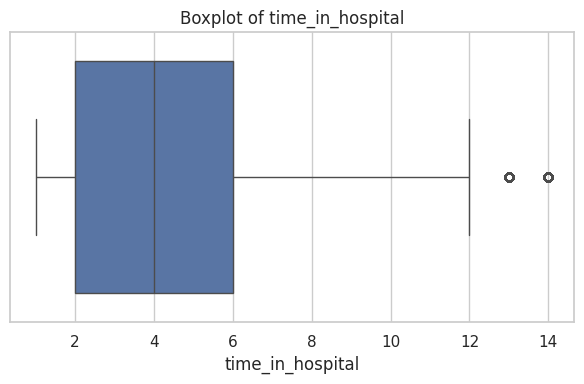

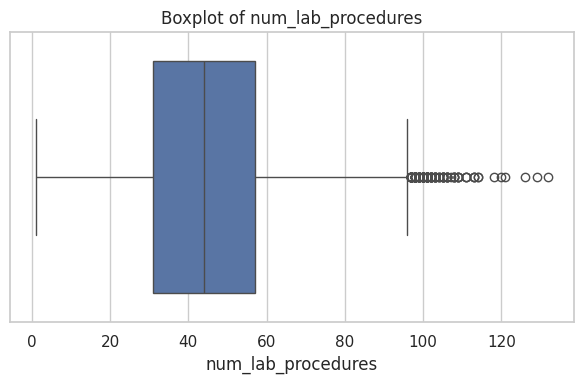

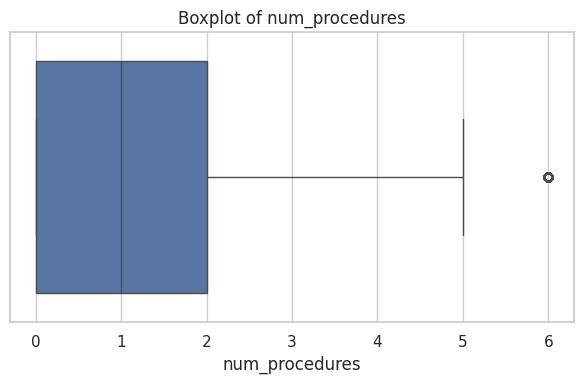

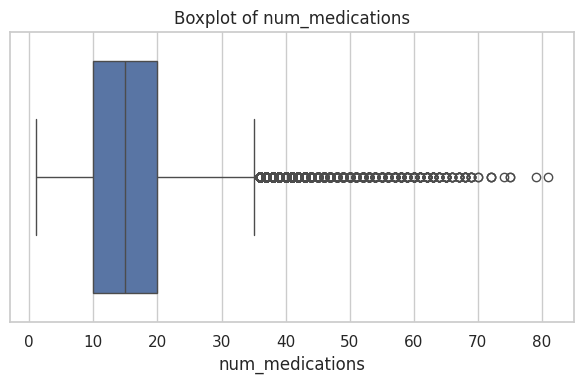

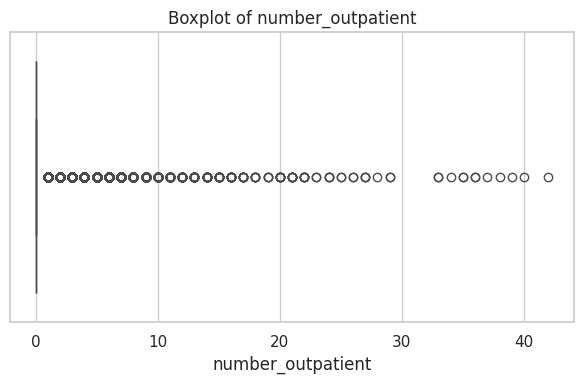

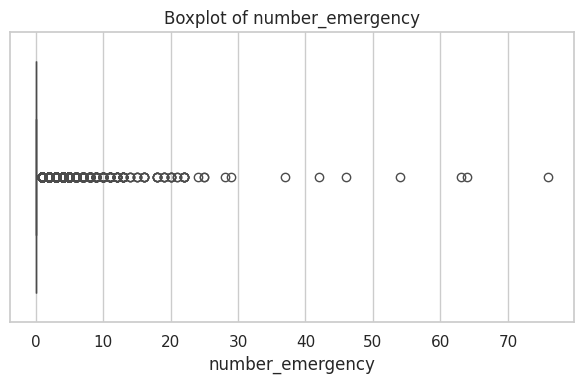

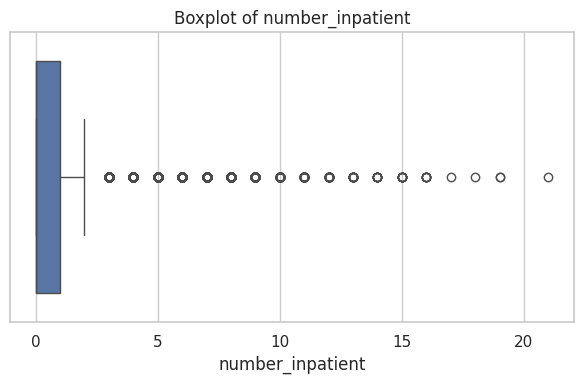

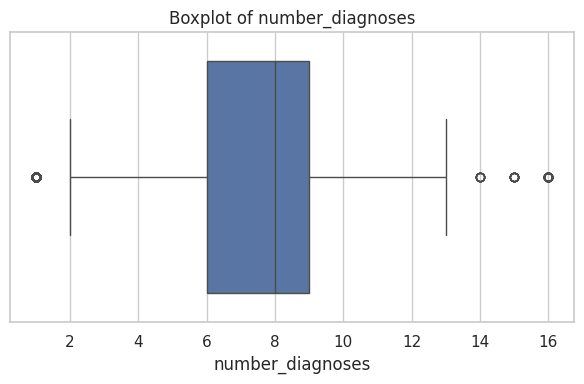

Number of outliers per numeric column (IQR method):


,0
number_diagnoses,101704
num_lab_procedures,101595
num_medications,98821
time_in_hospital,98066
number_inpatient,94717
num_procedures,93734
number_emergency,0
number_outpatient,0


In [49]:
10. #Outlier Checks (Simple IQR Method)

#Boxplots for numeric columns
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.title(f'Boxplot of {col}')
  plt.tight_layout()
  plt.show()

#IQR-based outlier detection summary
outlier_summary ={}

for col in num_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR
  outliers=df[(df[col]<lower)|(df[col]<upper)]
  outlier_summary[col] = outliers.shape[0]

print('Number of outliers per numeric column (IQR method):')
display(pd.Series(outlier_summary).sort_values(ascending=False))



In [50]:
#11.(Optional)Date/Time Features
date_col=None

if date_col is not None and date_col in df.colums:
   df[date_col]=pd.to_datetime(df[date_col],errors='coerce')

   df['year']=df[date-col].dt.year
   df['month']=df[date_col].dt.month
   df['day']=df[date_col].dt.day
   df['dayofweek']=df[date_col].dt.dayofweek

   print(df[[date_col,'year','month','day','dayofweek']].head())
else:
  print('No date_col set or column not found.Skipping datetime feature extraction')



No date_col set or column not found.Skipping datetime feature extraction


In [51]:
#12.GroupBY and Aggregations(Quick Patterns)

#Mean of numeric columns by target
if target_col is not None and target_col in df.columns:
  print(f"Mean numeric values grouped by target'{target_col}':")
  display(df.groupby(target_col)[num_cols].mean())

#Category vs target counts
example_cat= None #e.g.,'race'
if example_cat is not None and example_cat in df.columns and target_col in df.columns:
  print(f"\nCounts of {example_cat}by {target_col}:")
  display(df.groupby([example_cat,target_col]).size().unstack(fill_value=0))

# Aggregation for a chosen numeric column
agg_cat=None     # e.g.,'gender'
agg_num_col=None #  e.g.,'age'

if agg_cat is not None and agg_cat in df.columns and agg_num_col in df.columns:
  print(f"\nAggregations of {agg_num_col}by{agg_cat}:")
  display(df.groupby(agg_cat)[agg_num_col].agg(['count','mean','min','max']))

Mean numeric values grouped by target'age':


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
age,,,,,,,,
[0-10),2.546584,41.012422,0.180124,6.180124,0.012422,0.031056,0.080745,2.695652
[10-20),3.191027,43.096961,0.335745,8.277858,0.170767,0.156295,0.532562,3.947902
[20-30),3.564876,43.066385,0.767049,11.972842,0.366325,0.578153,1.338564,5.866626
[30-40),3.799735,43.033642,1.113377,14.091656,0.290861,0.490331,0.762649,6.452980
[40-50),4.039649,42.785958,1.341662,15.391017,0.329892,0.356840,0.724109,6.948787
[50-60),4.125753,42.611961,1.556096,16.584492,0.328002,0.222473,0.615090,7.238584
[60-70),4.382244,42.600632,1.573367,17.150425,0.388071,0.162434,0.606147,7.506427
[70-80),4.590878,43.157396,1.377896,16.407818,0.393011,0.131080,0.610365,7.651795
[80-90),4.808629,44.085015,1.023027,15.326685,0.417108,0.144269,0.609118,7.888702


In [52]:
#13. Save Cleaned/EDA-Ready Data

df_clean=df.copy()
output_file ='cleaned_data.csv'
df_clean.to_csv(output_file, index=False)
print(f'Cleaned data saved to {output_file}')

Cleaned data saved to cleaned_data.csv


**Conclusion:**

Diabetes data was analysed.


*   Data was uploded from GitHub repository
*   Data cleaning steps were performed. Missing values were identified and replaced with NaN
*   Duplicated rows and outlieres were checked.
*   As a further step, columns types were reassigned to correct category
*   Data statistics were calculated for all columns
*   Columns were vizualsed using barplots and there distributions was checked
*   Age (range) was selected as a target variable.
*   Age based comparision was done with A1C and insulin records
*   Age was also test againest number of procedures, hospital visits, and other numerical columns.
*   Code can be modifed to selct additional required comparison. Description text has been added in the code.
*   When required, findings were added at the end of the  each chunk of code.

